# Credit card approval dataset

Source: https://archive.ics.uci.edu/ml/datasets/Credit+Approval

In [37]:
# Import the pandas library. More information: https://pandas.pydata.org/
import pandas as pd

# Import the data as a pandas dataframe
credit_approval = pd.read_csv("/content/drive/MyDrive/Courses/2023 Fall CMPE 257/Colab/credit approval/crx.data", header = None)

credit_approval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [39]:
credit_approval[0].value_counts()

b    468
a    210
?     12
Name: 0, dtype: int64

Deal with ?s

In [40]:
credit_approval.isnull().values.sum()

0

In [41]:
# Import the numpy library for mathematical operations. More information: https://numpy.org/
import numpy as np

credit_approval = credit_approval.replace("?", np.NaN)
credit_approval.isnull().values.sum()

67

In [42]:
credit_approval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       678 non-null    object 
 1   1       678 non-null    object 
 2   2       690 non-null    float64
 3   3       684 non-null    object 
 4   4       684 non-null    object 
 5   5       681 non-null    object 
 6   6       681 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      677 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [43]:
credit_approval = credit_approval.fillna(credit_approval.mean())
print(credit_approval.info())

print("Number of nulls:", credit_approval.isnull().values.sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       678 non-null    object 
 1   1       678 non-null    object 
 2   2       690 non-null    float64
 3   3       684 non-null    object 
 4   4       684 non-null    object 
 5   5       681 non-null    object 
 6   6       681 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      677 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB
None
Number of nulls: 67


<ipython-input-43-731a0666dc51>:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  credit_approval = credit_approval.fillna(credit_approval.mean())


In [44]:
for column in credit_approval.columns:
  credit_approval[column] = credit_approval[column].fillna(credit_approval[column].value_counts().index[0])
print(credit_approval.info())

print("Number of nulls:", credit_approval.isnull().values.sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB
None
Number of nulls: 0


Preprocessing

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
print(credit_approval[1])
temp = le.fit_transform(credit_approval[1])
print(temp)

0      30.83
1      58.67
2      24.50
3      27.83
4      20.17
       ...  
685    21.08
686    22.67
687    25.25
688    17.92
689    35.00
Name: 1, Length: 690, dtype: object
[156 328  89 125  43 168 179  74 310 255  64 145 220 282 270 211 129  78
  61  34  94  78 280 121 244   3 274 318 322 252 138 251 291 212  70 125
 119  75 124 311 188 136 142 234 316 309 243 166 247  84 103 106 215 196
 189  79  77 265 198 261 319 163  80  46 113 188 203 100  36 198 171 195
 223 264 266  48 187  34  59  57 292 123 235  71 119 213  71 102 186 289
 334 161  71 303 135 133  75  71  69 132 216 199  29  94 125 312 135  94
 242  40 137  89  90 184  48  99 218 305 324  49 236 102  91 263  81 196
 279  72 190 131 340  46 278 206 173 287 236 182  31 116 159 317 258  67
 119 175  78 239 152 306 273 325 214  76 174  59 132 341 126 187 123 262
  95 167 332 241  35 171 211 216  95 245 315 293  71 117  94 107  26  43
 279  54  48 321  68 288 237 240 134 178  55 251 249  71 191 129 179 283
 122  70  85 245  

In [46]:
for column in credit_approval.columns:
  if credit_approval[column].dtype == "object":
    credit_approval[column] = le.fit_transform(credit_approval[column])
credit_approval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    int64  
 1   1       690 non-null    int64  
 2   2       690 non-null    float64
 3   3       690 non-null    int64  
 4   4       690 non-null    int64  
 5   5       690 non-null    int64  
 6   6       690 non-null    int64  
 7   7       690 non-null    float64
 8   8       690 non-null    int64  
 9   9       690 non-null    int64  
 10  10      690 non-null    int64  
 11  11      690 non-null    int64  
 12  12      690 non-null    int64  
 13  13      690 non-null    int64  
 14  14      690 non-null    int64  
 15  15      690 non-null    int64  
dtypes: float64(2), int64(14)
memory usage: 86.4 KB


In [47]:
credit_approval.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,156,0.000,1,0,12,7,1.25,1,1,1,0,0,68,0,0
1,0,328,4.460,1,0,10,3,3.04,1,1,6,0,0,11,560,0
2,0,89,0.500,1,0,10,3,1.50,1,0,0,0,0,96,824,0
3,1,125,1.540,1,0,12,7,3.75,1,1,5,1,0,31,3,0
4,1,43,5.625,1,0,12,7,1.71,1,0,0,0,2,37,0,0


In [48]:
from sklearn.preprocessing import MinMaxScaler
def preprocess(data):
  scaler = MinMaxScaler(feature_range=(0, 1))
  return scaler.fit_transform(data)

## Machine Learning Module

Training Validation Testing

In [49]:
#Split training and testing

from sklearn.model_selection import train_test_split

#Unnecessary features based on: http://rstudio-pubs-static.s3.amazonaws.com/73039_9946de135c0a49daa7a0a9eda4a67a72.html
credit_approval = credit_approval.drop([11, 13], axis=1)
ca_arr = credit_approval.values



In [50]:
# Segregate features and labels into separate variables
X,y = ca_arr[:,0:12] , ca_arr[:,13]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33)

In [51]:
scaler = MinMaxScaler()
# transform data
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.metrics import confusion_matrix


# Decision Trees

In [56]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(criterion="entropy",min_samples_split=4,max_depth=5)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=4)

In [57]:
y_pred = dt_clf.predict(X_test)
print("Accuracy: ", dt_clf.score(X_test, y_test))
print("Confusion Matrix: ")
confusion_matrix(y_test, y_pred)

Accuracy:  0.8333333333333334
Confusion Matrix: 


array([[ 90,  15],
       [ 23, 100]])

In [58]:
y_pred = dt_clf.predict(X_train)
print("Accuracy: ", dt_clf.score(X_train, y_train))
print("Confusion Matrix: ")
confusion_matrix(y_train, y_pred)

Accuracy:  0.9090909090909091
Confusion Matrix: 


array([[189,  13],
       [ 29, 231]])

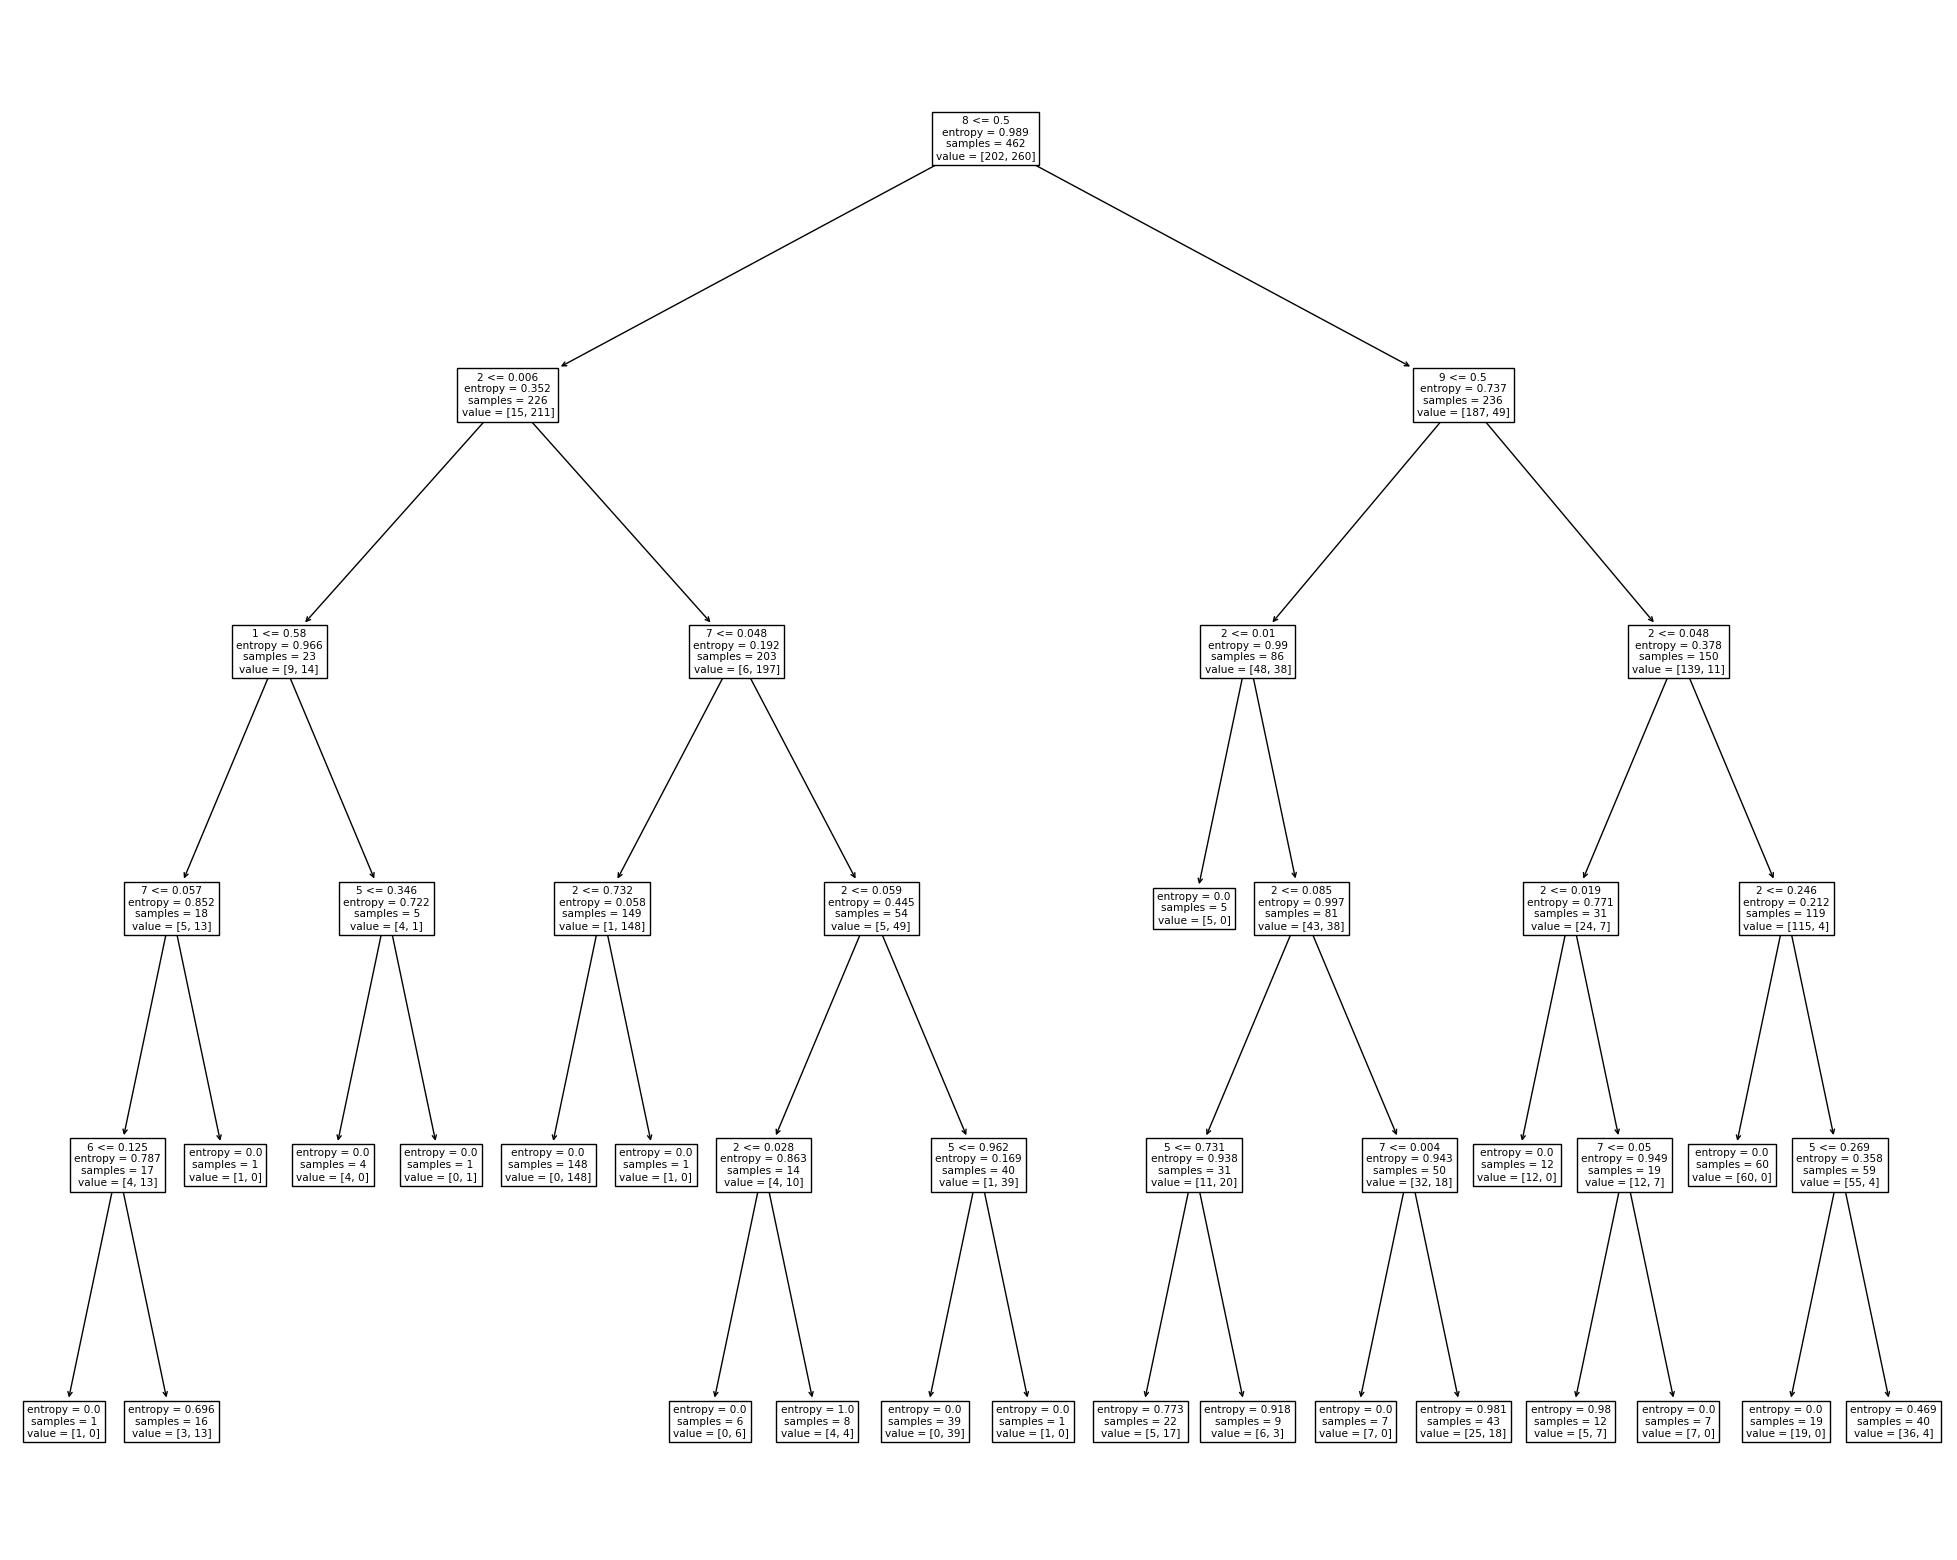

In [59]:
from sklearn import tree
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(25,20))
fig = tree.plot_tree(dt_clf, feature_names=credit_approval.keys())

Random Forest

In [61]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=20, criterion='entropy',)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=20)

In [63]:
y_pred = rf_clf.predict(X_test)
print("Accuracy: ", rf_clf.score(X_test, y_test))
print("Confusion Matrix: ")
confusion_matrix(y_test, y_pred)

Accuracy:  0.8508771929824561
Confusion Matrix: 


array([[ 89,  16],
       [ 18, 105]])